## Setup: Import All Required Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("All libraries imported successfully")

All libraries imported successfully


## TASK 1: Data Loading & Exploration

In [2]:
df = pd.read_csv('Housing.csv')
print("File loaded successfully")

File loaded successfully


In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 545
Columns: 13


In [5]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [6]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## TASK 2: Data Cleaning

In [7]:
print(f"Duplicated Rows: {df.duplicated().sum()}")

Duplicated Rows: 0


In [8]:
print(df.dtypes)

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


In [9]:
yes_no_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating','airconditioning','prefarea',]

for column in yes_no_columns:
    df[column] = df[column].map({'yes':1,'no':0})

In [10]:
print(df['mainroad'].unique())
print(df['guestroom'].unique())

[1 0]
[0 1]


In [11]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


# Task 3 - Model Building

# Step 1: Separate Features and Target

In [14]:
X = df.drop(columns=['price'])
y = df['price']

print(f"Feature (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Feature (X) shape: (545, 13)
Target (y) shape: (545,)


# Step 2: Split Data 80/20

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]}houses")
print(f"Testing set: {X_test.shape[0]}houses")

Training set: 436houses
Testing set: 109houses


# Step 3: Train Linear Regression Model

In [16]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_lr = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE:  {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R² Score: {r2:.4f}")

MAE:  970,043
RMSE: 1,324,507
R² Score: 0.6529


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor Model Trained")

Random Forest Regressor Model Trained


In [19]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [20]:
print(f"MAE: {mae_rf:,.0f}")
print(f"RMSE: {rmse_rf:,.0f}")
print(f"R² Score: {r2_rf:.4f}")

MAE: 1,022,560
RMSE: 1,401,497
R² Score: 0.6114


# Task 4 - Chart 

# Chart1: Price Distribution Histogram

<function matplotlib.pyplot.show(close=None, block=None)>

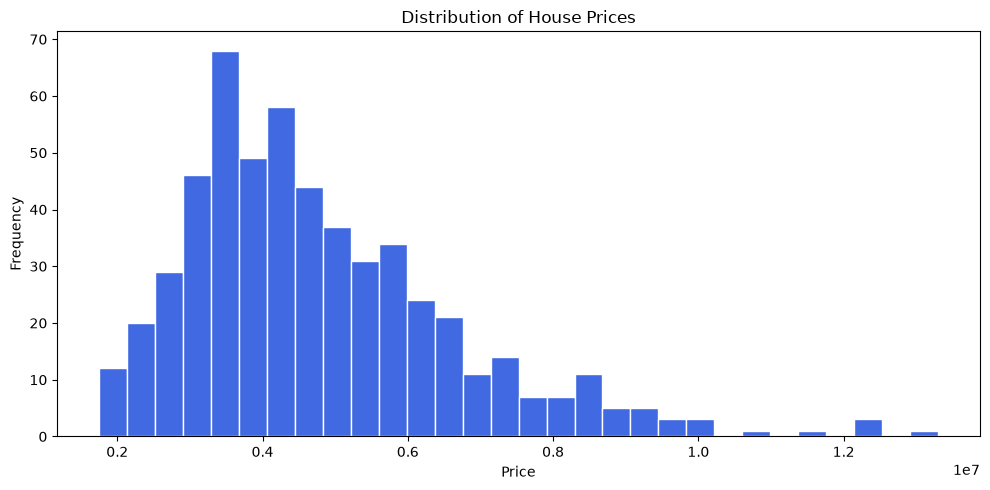

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=30, color= 'royalblue', edgecolor= 'white')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Chart_1_price_distribution.png')
plt.show

# Chart 2: Correlation Heatmap

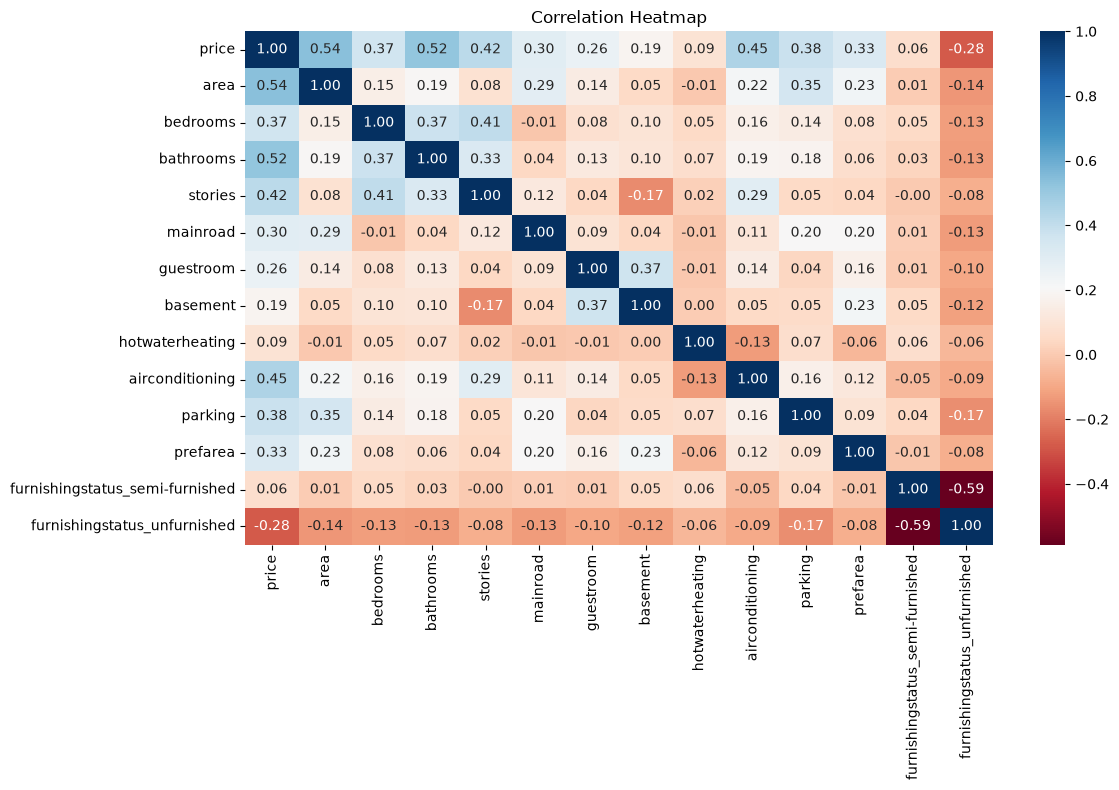

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt= '.2f', cmap= 'RdBu')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('chart_2_correlation_heatmap.png')
plt.show()

# Chart 3: Actual vs Predicted Prices

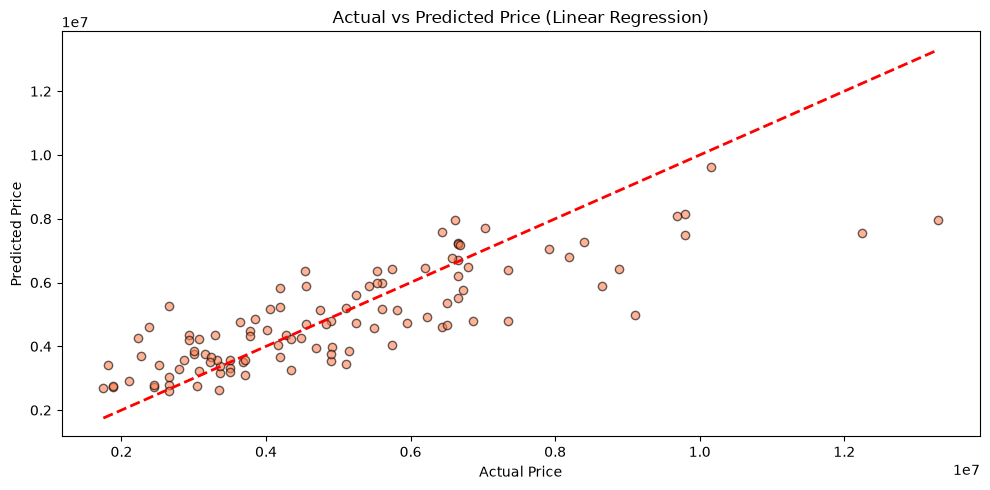

In [23]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lr, color= 'coral', edgecolor= 'black', alpha= 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw= 2)
plt.title('Actual vs Predicted Price (Linear Regression)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('chart_3_actual_vs_predicted.png')
plt.show()


## Task 5 - Insights & Summary

**Which features influence house price the most?**
Area, number of bathrooms and stories are the strongest 
predictors of house price based on the correlation heatmap.

**How accurate was your model?**
Linear Regression achieved an R² score of 0.65, meaning it 
correctly explained 65% of price variation in the dataset.

**What surprised you?**
Linear Regression outperformed Random Forest despite Random 
Forest being a more complex model.

**Business Recommendation:**
Real estate agents should focus on area and number of 
bathrooms as key pricing factors when valuing properties.